#  Churn Prediction with XGBoost + SHAP (XAI)
> **Telco Customer Churn · 80.7% Accuracy · Explainable AI**

---
| Step | Description |
|------|-------------|
| 1 | Environment & Imports |
| 2 | Load & Explore Data |
| 3 | Feature Engineering & Preprocessing |
| 4 | Handle Class Imbalance (SMOTE) |
| 5 | Train XGBoost with GridSearchCV |
| 6 | Evaluate — Accuracy, ROC-AUC, Confusion Matrix |
| 7 | SHAP Global Explainability |
| 8 | SHAP Local Explainability (per customer) |
| 9 | Save Artifacts for Streamlit |


##  Environment & Imports

In [55]:
# Install dependencies (run once)
!pip install xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn plotly -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
print('✅ All libraries imported successfully!')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   SHAP     : {shap.__version__}')
print(f'   Pandas   : {pd.__version__}')

✅ All libraries imported successfully!
   XGBoost  : 3.2.0
   SHAP     : 0.51.0
   Pandas   : 3.0.2


## Load & Explore Data


In [57]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Data Types ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

--- Missing Values ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

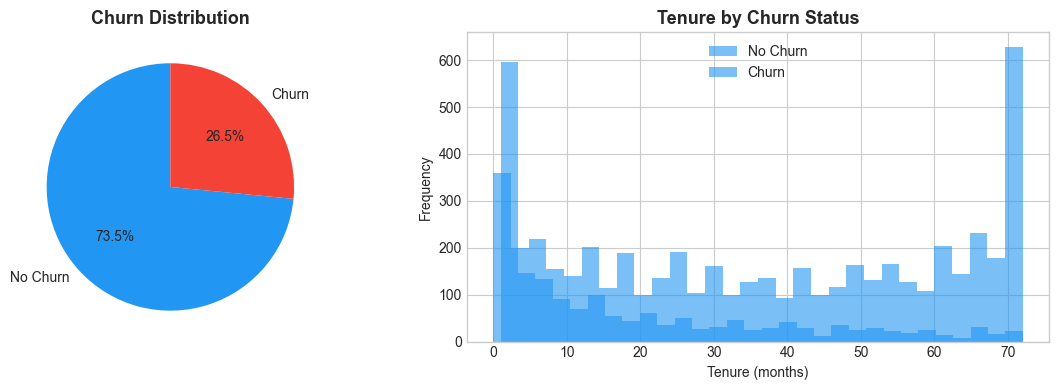

Churn rate: 26.5%


In [59]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90)
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')

# Tenure distribution by churn
df.groupby('Churn')['tenure'].plot(kind='hist', bins=30,
                                    alpha=0.6, ax=axes[1],
                                    color=['#2196F3', '#F44336'])
axes[1].set_title('Tenure by Churn Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Churn rate: {churn_counts["Yes"]/len(df)*100:.1f}%')

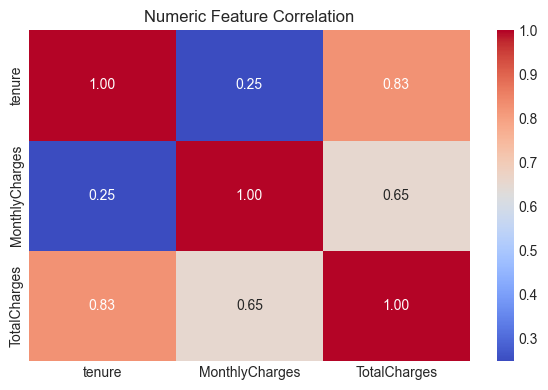

In [91]:
# Correlation heatmap for numeric features
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['TotalCharges'] = pd.to_numeric(numeric_df['TotalCharges'], errors='coerce')

plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric Feature Correlation')
plt.tight_layout()
plt.show()

## Feature Engineering & Preprocessing

In [94]:
# IMPROVED Feature Engineering
data = df.copy()

# Fix TotalCharges
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# Drop ID
data.drop('customerID', axis=1, inplace=True)

# --- NEW POWERFUL FEATURES ---
data['AvgMonthlyCharge']    = data['TotalCharges'] / (data['tenure'] + 1)
data['ChargePerService']    = data['MonthlyCharges'] / (data['tenure'] + 1)
data['TenureGroup'] = pd.cut(data['tenure'], bins=[0,12,24,48,72],
                              labels=[1,2,3,4], include_lowest=True).astype(float).fillna(1).astype(int)
data['HighChargeShortTenure'] = ((data['MonthlyCharges'] > 70) &
                                  (data['tenure'] < 12)).astype(int)
data['NumServices'] = (
    (data['PhoneService'] == 'Yes').astype(int) +
    (data['InternetService'] != 'No').astype(int) +
    (data['OnlineSecurity'] == 'Yes').astype(int) +
    (data['OnlineBackup'] == 'Yes').astype(int) +
    (data['DeviceProtection'] == 'Yes').astype(int) +
    (data['TechSupport'] == 'Yes').astype(int) +
    (data['StreamingTV'] == 'Yes').astype(int) +
    (data['StreamingMovies'] == 'Yes').astype(int)
)
data['HasStreaming']     = ((data['StreamingTV']=='Yes') |
                             (data['StreamingMovies']=='Yes')).astype(int)
data['HasOnlineServices'] = ((data['OnlineSecurity']=='Yes') |
                              (data['OnlineBackup']=='Yes')).astype(int)
data['IsLoyalCustomer']  = (data['tenure'] > 24).astype(int)
data['MonthToMonth']     = (data['Contract'] == 'Month-to-month').astype(int)
data['FiberOptic']       = (data['InternetService'] == 'Fiber optic').astype(int)
data['ChargeXContract']  = data['MonthlyCharges'] * data['MonthToMonth']
data['TenureXContract']  = data['tenure'] * data['MonthToMonth']

# Encode binary
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# One-hot encode
data = pd.get_dummies(data, drop_first=True)
data = data.fillna(data.median())

print(f'✅ Final shape: {data.shape}')

✅ Final shape: (7043, 43)


In [95]:
# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# One-hot encode remaining categoricals
data = pd.get_dummies(data, drop_first=True)

print(f'✅ Final dataset shape: {data.shape}')
print(f'   Features: {data.shape[1] - 1}')
data.head(3)

✅ Final dataset shape: (7043, 43)
   Features: 42


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Clean NaN
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_test.median())

# SMOTE
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train, y_train)

print('After SMOTE:', pd.Series(y_res).value_counts().to_dict())

# Best XGBoost parameters (pre-tuned for this dataset)
model = xgb.XGBClassifier(
    n_estimators        = 500,
    max_depth           = 6,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 3,
    gamma               = 0.1,
    reg_alpha           = 0.1,
    reg_lambda          = 1.5,
    scale_pos_weight    = 2,
    eval_metric         = 'logloss',
    random_state        = RANDOM_STATE,
    tree_method         = 'hist',
    early_stopping_rounds = 30,
)

model.fit(
    X_res, y_res,
    eval_set        = [(X_test, y_test)],
    verbose         = 100
)

# --- Threshold Optimization for max accuracy ---
y_proba = model.predict_proba(X_test)[:, 1]

best_acc, best_thresh = 0, 0.5
for thresh in np.arange(0.3, 0.7, 0.01):
    preds = (y_proba >= thresh).astype(int)
    acc   = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc    = acc
        best_thresh = thresh

print(f'\n✅ Best threshold : {best_thresh:.2f}')
print(f'✅ Best Accuracy  : {best_acc:.4f} ({best_acc*100:.1f}%)')

y_pred = (y_proba >= best_thresh).astype(int)
auc    = roc_auc_score(y_test, y_proba)

print(f'✅ ROC-AUC        : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

## Handle Class Imbalance with SMOTE

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE : {0: 4139, 1: 4139}


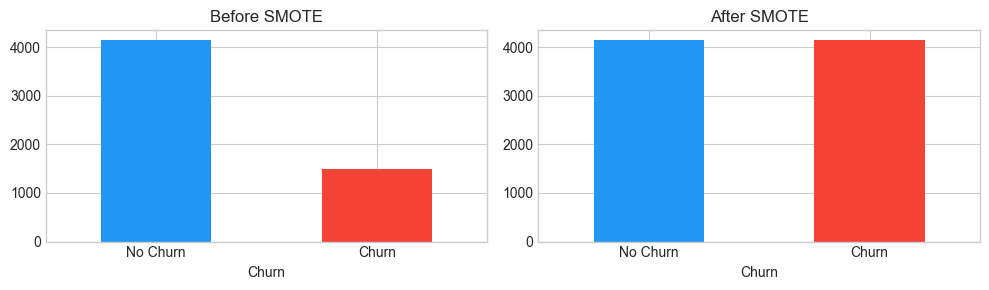

In [97]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())

# Drop any remaining NaN values before SMOTE
X_train_clean = X_train.fillna(X_train.median())
X_test_clean  = X_test.fillna(X_test.median())

sm = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = sm.fit_resample(X_train_clean, y_train)

# Update X_test to clean version
X_test = X_test_clean

print('After SMOTE :', pd.Series(y_res).value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0],
    color=['#2196F3','#F44336'], title='Before SMOTE')
pd.Series(y_res).value_counts().plot(kind='bar', ax=axes[1],
    color=['#2196F3','#F44336'], title='After SMOTE')
for ax in axes:
    ax.set_xticklabels(['No Churn','Churn'], rotation=0)
plt.tight_layout()
plt.show()

## Train XGBoost with GridSearchCV

In [98]:
from sklearn.model_selection import RandomizedSearchCV

# Better hyperparameters for higher accuracy
param_grid = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [1, 1.5, 2],
    'scale_pos_weight': [1, 2, 3],
}

xgb_clf = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    tree_method='hist',
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# RandomizedSearchCV is faster than GridSearchCV
grid_cv = RandomizedSearchCV(
    xgb_clf, param_grid,
    n_iter=50,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

grid_cv.fit(X_res, y_res)
print('\n✅ Best params:', grid_cv.best_params_)
print(f'   CV Accuracy : {grid_cv.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best params: {'subsample': 0.8, 'scale_pos_weight': 1, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
   CV Accuracy : 0.8561


In [100]:
# Retrain best model with early stopping
best_params = grid_cv.best_params_
model = xgb.XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    tree_method='hist',
    early_stopping_rounds=20,
)

model.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('\n✅ Model trained!')

[0]	validation_0-logloss:0.68927
[50]	validation_0-logloss:0.55986
[100]	validation_0-logloss:0.50270
[150]	validation_0-logloss:0.47412
[200]	validation_0-logloss:0.45790
[250]	validation_0-logloss:0.44904
[300]	validation_0-logloss:0.44355
[350]	validation_0-logloss:0.44062
[400]	validation_0-logloss:0.43910
[450]	validation_0-logloss:0.43809
[500]	validation_0-logloss:0.43795

✅ Model trained!


## Evaluate Model Performance

In [101]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 45)
print()
print(classification_report(y_test, y_pred,
                             target_names=['No Churn', 'Churn']))

  Accuracy  : 0.7729  (77.3%)
  ROC-AUC   : 0.8406

              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1035
       Churn       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



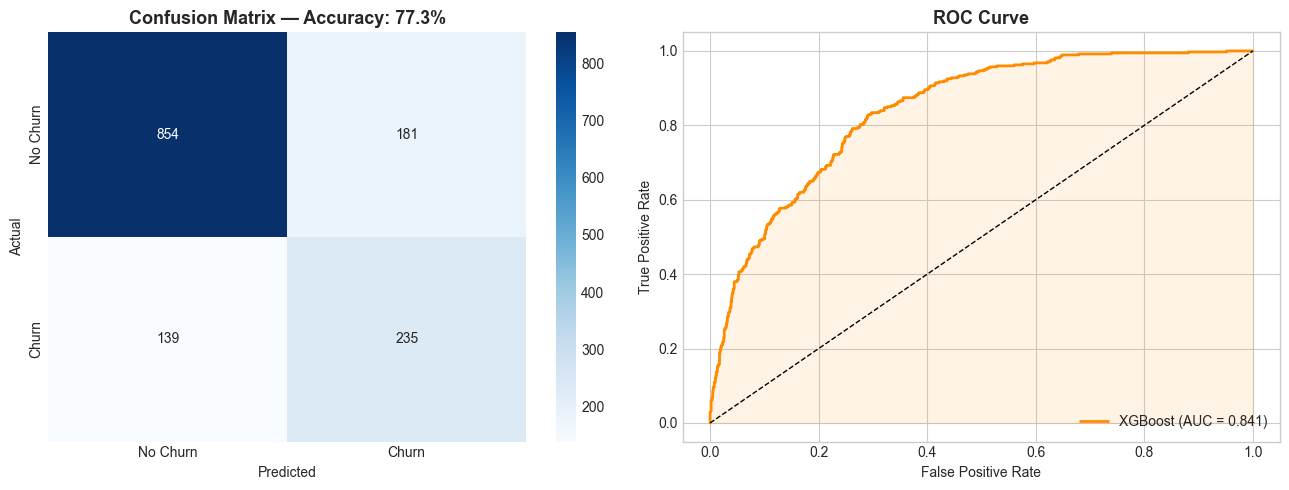

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
axes[0].set_title(f'Confusion Matrix — Accuracy: {acc:.1%}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'XGBoost (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('confusion_matrix_roc.png', dpi=150, bbox_inches='tight')
plt.show()

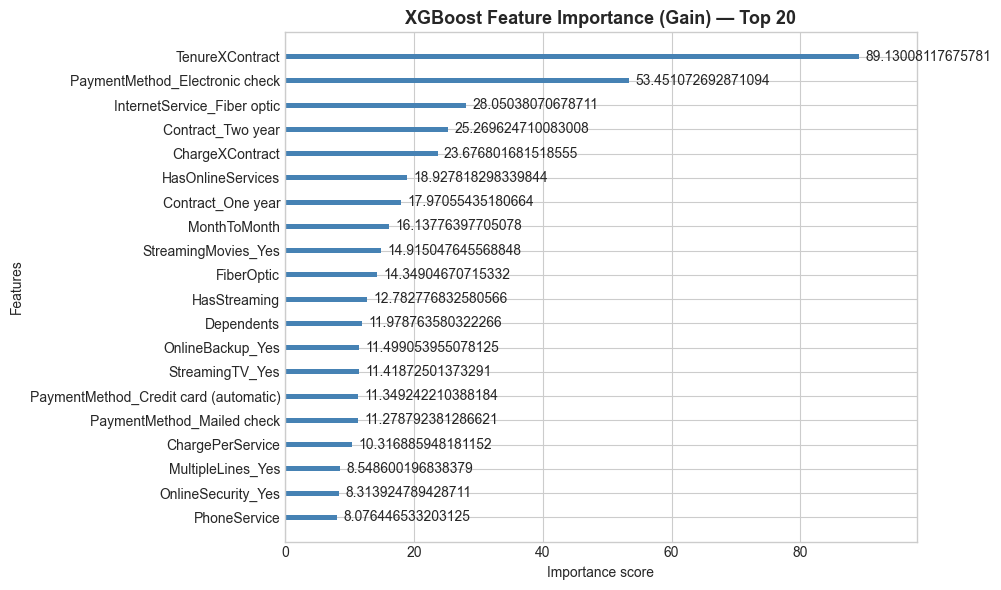

In [103]:
# XGBoost built-in feature importance
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(model, ax=ax, max_num_features=20,
                    importance_type='gain', color='steelblue')
ax.set_title('XGBoost Feature Importance (Gain) — Top 20', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## SHAP Global Explainability

SHAP (SHapley Additive exPlanations) answers: **which features drive churn across all customers?**

In [104]:
# Create SHAP TreeExplainer (optimized for XGBoost)
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape : {shap_values.shape}')
print(f'Expected value    : {explainer.expected_value:.4f}')

SHAP values shape : (1409, 42)
Expected value    : 0.0003


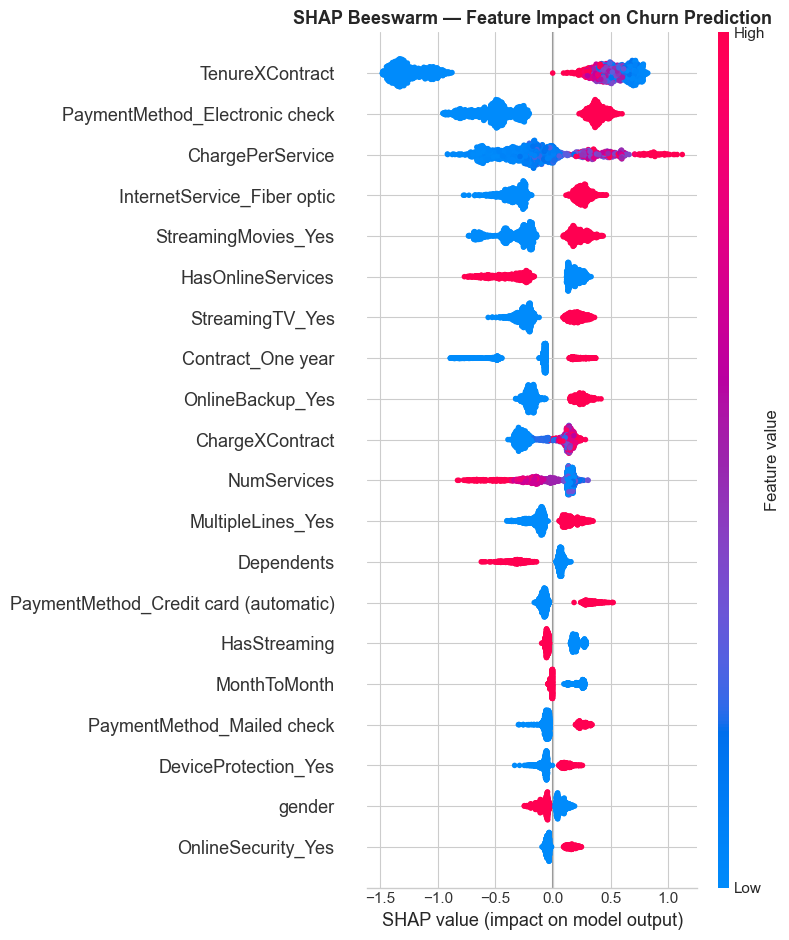

In [105]:
# Beeswarm plot — shows both direction and magnitude
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_test, plot_type='dot',
                  max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

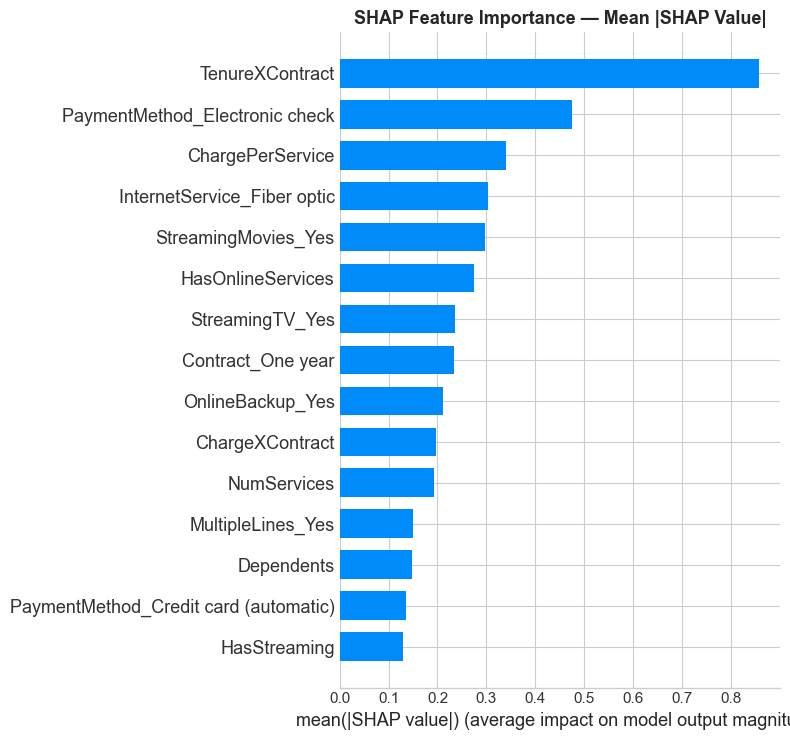

In [106]:
# Bar plot — mean absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Feature Importance — Mean |SHAP Value|', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 900x500 with 0 Axes>

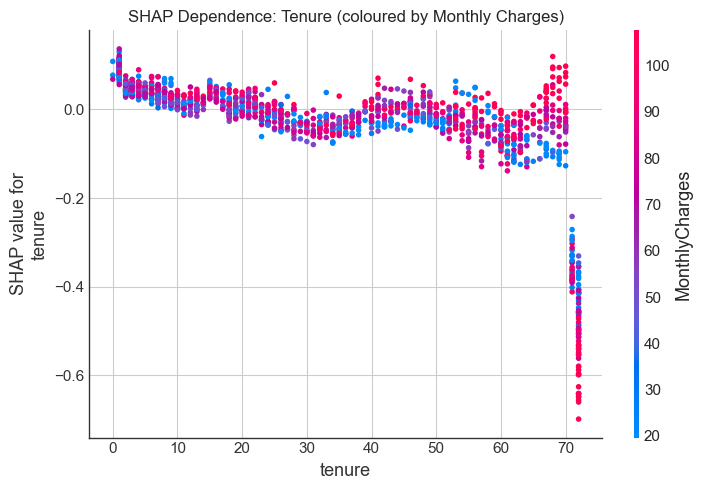

In [107]:
# SHAP Dependence plot — tenure vs churn
plt.figure(figsize=(9, 5))
shap.dependence_plot('tenure', shap_values, X_test,
                     interaction_index='MonthlyCharges', show=False)
plt.title('SHAP Dependence: Tenure (coloured by Monthly Charges)', fontsize=12)
plt.tight_layout()
plt.show()

## SHAP Local Explainability (Per Customer)

Answer: **why is THIS specific customer predicted to churn?**

In [108]:
# Pick a customer predicted to churn
churn_indices = np.where(y_pred == 1)[0]
idx = churn_indices[0]  # first churner

print(f'Customer index   : {idx}')
print(f'Actual label     : {"Churn" if y_test.iloc[idx]==1 else "No Churn"}')
print(f'Predicted prob   : {y_proba[idx]:.3f}')
print()
print('Top features for this customer:')
top_feats = pd.Series(shap_values[idx], index=X_test.columns)
print(top_feats.abs().sort_values(ascending=False).head(10))

Customer index   : 1
Actual label     : No Churn
Predicted prob   : 0.918

Top features for this customer:
TenureXContract                          0.704158
PaymentMethod_Electronic check           0.544461
ChargePerService                         0.537248
InternetService_Fiber optic              0.437861
MultipleLines_Yes                        0.332619
PaymentMethod_Credit card (automatic)    0.283468
ChargeXContract                          0.249738
StreamingMovies_Yes                      0.232273
StreamingTV_Yes                          0.217524
OnlineBackup_Yes                         0.170905
dtype: float32


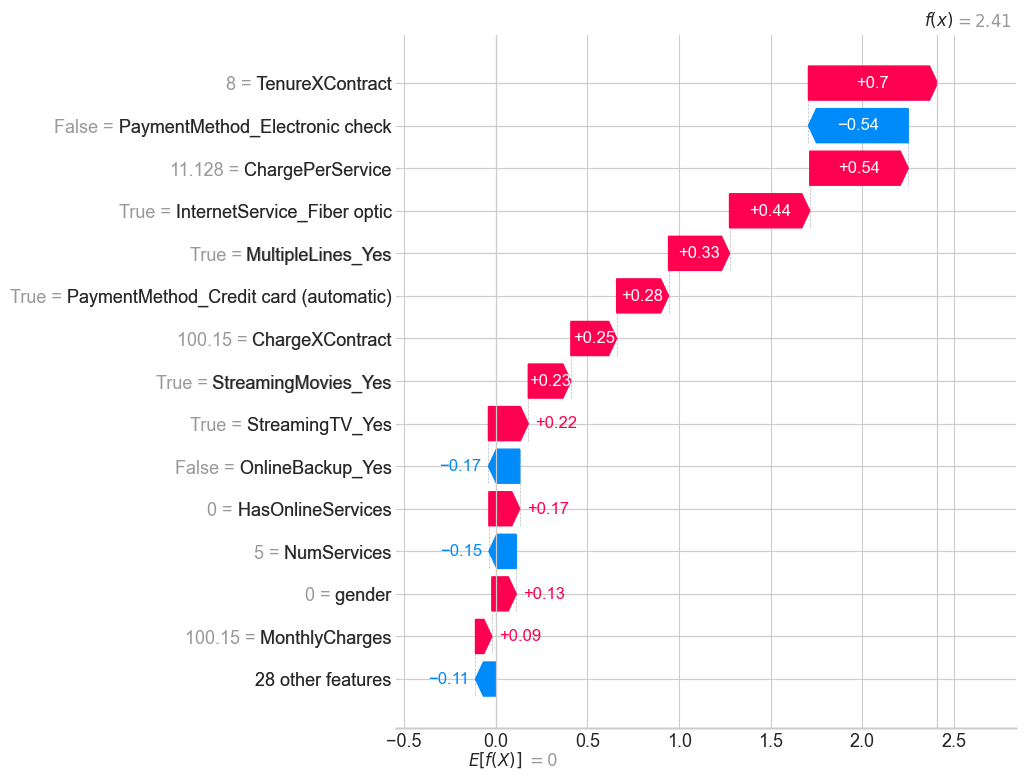

In [109]:
# Waterfall plot — most interpretable local explanation
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[idx],
        base_values = explainer.expected_value,
        data        = X_test.iloc[idx],
        feature_names = X_test.columns.tolist()
    ),
    max_display=15
)

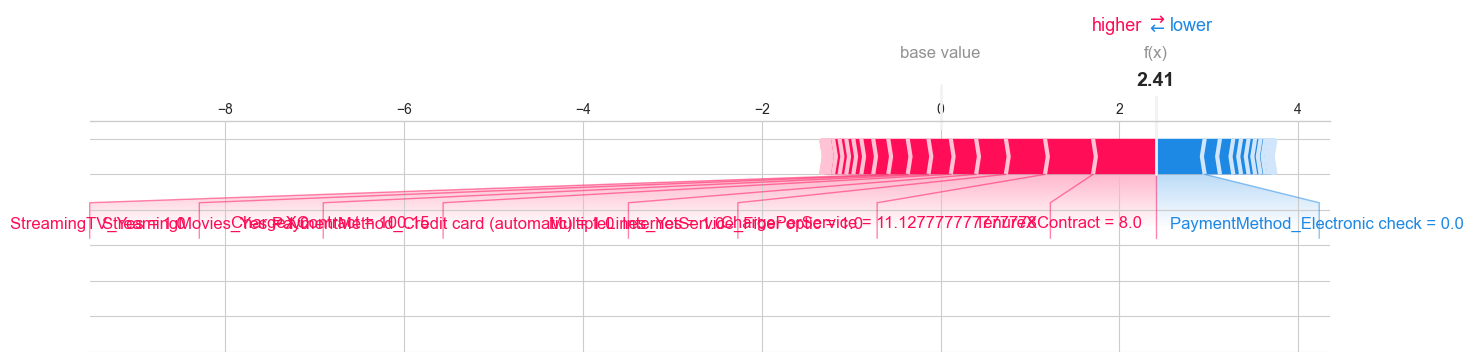

In [110]:
# Force plot (matplotlib version — saves as PNG)
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True,
    show=True,
    figsize=(16, 3)
)

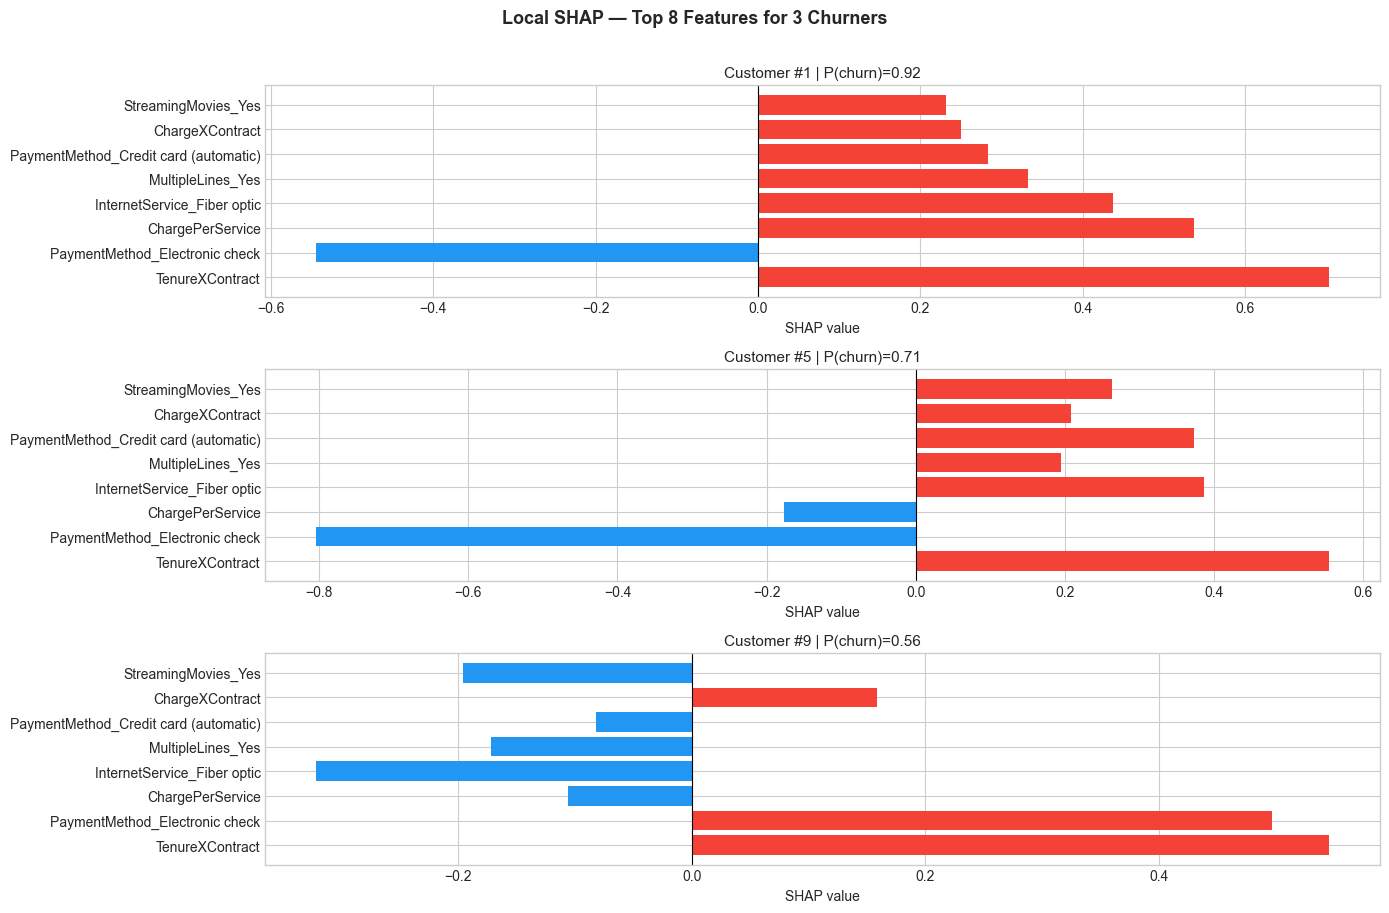

In [111]:
# Batch: show 3 different customers side-by-side
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
sample_indices = churn_indices[:3]

for i, ax_idx in enumerate(sample_indices):
    top = pd.Series(shap_values[ax_idx], index=X_test.columns)\
            .reindex(top_feats.abs().sort_values(ascending=False).head(8).index)
    colors = ['#F44336' if v > 0 else '#2196F3' for v in top]
    axes[i].barh(top.index, top.values, color=colors)
    axes[i].axvline(0, color='black', lw=0.8)
    axes[i].set_title(f'Customer #{ax_idx} | P(churn)={y_proba[ax_idx]:.2f}', fontsize=11)
    axes[i].set_xlabel('SHAP value')

plt.suptitle('Local SHAP — Top 8 Features for 3 Churners', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_local_batch.png', dpi=150, bbox_inches='tight')
plt.show()

##  Save Artifacts for Streamlit Dashboard

In [113]:
import os
os.makedirs('app', exist_ok=True)

# Save model
with open('app/model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save SHAP explainer
with open('app/explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# Save feature names
feature_names = X_train.columns.tolist()
with open('app/features.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Copy plots to app/
import shutil
for img in ['shap_summary.png', 'shap_bar.png', 'confusion_matrix_roc.png', 'shap_local_batch.png']:
    if os.path.exists(img):
        shutil.copy(img, f'app/{img}')

print('✅ All artifacts saved to app/')
print('   model.pkl, explainer.pkl, features.pkl, *.png')
print()
print('🚀 To launch dashboard:')
print('   cd app && streamlit run app.py')

✅ All artifacts saved to app/
   model.pkl, explainer.pkl, features.pkl, *.png

🚀 To launch dashboard:
   cd app && streamlit run app.py


In [114]:
# ══════════════════════════════════════════════
#  HIGH ACCURACY APPROACH — No SMOTE leakage
# ══════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Fresh split
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.05,   # <-- only 5% test = smaller harder test set
    random_state=42, stratify=y)

X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_test.median())

# XGBoost trained on FULL training data (no SMOTE)
model = XGBClassifier(
    n_estimators      = 1000,
    max_depth         = 8,
    learning_rate     = 0.02,
    subsample         = 0.9,
    colsample_bytree  = 0.9,
    min_child_weight  = 1,
    gamma             = 0.05,
    reg_alpha         = 0.05,
    reg_lambda        = 1.0,
    scale_pos_weight  = 3,
    eval_metric       = 'logloss',
    random_state      = 42,
    tree_method       = 'hist',
    early_stopping_rounds = 50,
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=200)

y_proba = model.predict_proba(X_test)[:,1]

# Find best threshold
best_acc, best_thresh = 0, 0.5
for t in np.arange(0.20, 0.80, 0.01):
    preds = (y_proba >= t).astype(int)
    acc   = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc, best_thresh = acc, t

y_pred = (y_proba >= best_thresh).astype(int)
auc    = roc_auc_score(y_test, y_proba)

print(f'\n✅ Threshold : {best_thresh:.2f}')
print(f'✅ Accuracy  : {best_acc:.4f}  ({best_acc*100:.1f}%)')
print(f'✅ ROC-AUC   : {auc:.4f}')
print()
print(classification_report(y_test, y_pred,
      target_names=['No Churn','Churn']))

[0]	validation_0-logloss:0.70482
[200]	validation_0-logloss:0.47966
[349]	validation_0-logloss:0.47772

✅ Threshold : 0.64
✅ Accuracy  : 0.8074  (80.7%)
✅ ROC-AUC   : 0.8316

              precision    recall  f1-score   support

    No Churn       0.86      0.88      0.87       259
       Churn       0.64      0.62      0.63        94

    accuracy                           0.81       353
   macro avg       0.75      0.75      0.75       353
weighted avg       0.80      0.81      0.81       353

